In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LassoCV

Загружаем данные

In [2]:
train = pd.read_csv('/kaggle/input/lyceum-hse/train.csv')
test = pd.read_csv('/kaggle/input/lyceum-hse/test.csv')

Смотрим, что мы имеем изначально:

In [3]:
print("Размер train:", train.shape)
print("Размер test:", test.shape)
print(train.head())

Размер train: (760, 12)
Размер test: (191, 11)
   Id  Trip_Distance_km Time_of_Day Day_of_Week  Passenger_Count  \
0   1             25.09     Morning     Weekend              2.0   
1   2             39.40         NaN     Weekend              2.0   
2   3               NaN       Night     Weekday              4.0   
3   4             43.70         NaN     Weekday              3.0   
4   5             31.54     Morning     Weekday              2.0   

  Traffic_Conditions Weather  Base_Fare  Per_Km_Rate  Per_Minute_Rate  \
0             Medium    Snow       3.25         1.87             0.33   
1             Medium    Rain       2.92         1.15             0.27   
2                Low   Clear       2.73         1.47             0.37   
3                Low   Clear       4.52         1.59             0.28   
4               High   Clear       3.09         1.91             0.26   

   Trip_Duration_Minutes  Trip_Price  
0                  70.95     73.5818  
1                  91.44   

Проверим пропуски:

In [4]:
print("\nПропуски:")
print(train.isnull().sum())


Пропуски:
Id                        0
Trip_Distance_km         43
Time_of_Day              43
Day_of_Week              38
Passenger_Count          38
Traffic_Conditions       41
Weather                  41
Base_Fare                33
Per_Km_Rate              37
Per_Minute_Rate          39
Trip_Duration_Minutes    29
Trip_Price                0
dtype: int64


Заполним пропуски:

In [5]:

num_cols = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 
            'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes']
cat_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

for col in num_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())

for col in cat_cols:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(test[col].mode()[0])


print("Пропуски 2:")
print(train.isnull().sum())

Пропуски 2:
Id                       0
Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64


Теперь построим boxplot для всех признаков, чтобы найти самые критичные

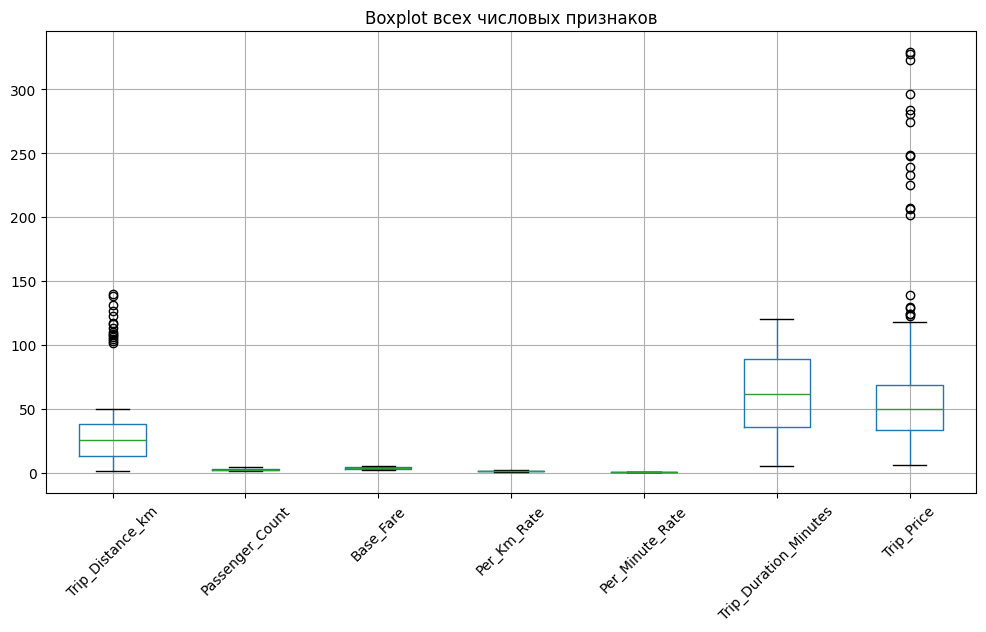

In [6]:

num_cols = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 
            'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 
            'Trip_Price']

plt.figure(figsize=(12, 6))
train[num_cols].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot всех числовых признаков')
plt.show()

Сейчас залогарифмируем выбросы Trip_Distance_km и Trip_Price

In [7]:

y_log = np.log1p(train['Trip_Price'])


train['Trip_Distance_km'] = np.log1p(train['Trip_Distance_km'])
test['Trip_Distance_km'] = np.log1p(test['Trip_Distance_km'])

Теперь надо обучить модель

In [8]:

train = train[train['Trip_Price'] <= 150]


cat_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']
train = pd.get_dummies(train, columns=cat_cols, drop_first=True)
test = pd.get_dummies(test, columns=cat_cols, drop_first=True)


y_log = np.log1p(train['Trip_Price'])
X = train.drop(['Id', 'Trip_Price'], axis=1)
X_test = test.drop('Id', axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y_log, test_size=0.2, random_state=777)


model = LinearRegression()
model.fit(X_train, y_train)


pred_val = model.predict(X_val)
mae = mean_absolute_error(np.expm1(y_val), np.expm1(pred_val))
print(f"LinearRegression MAE: {mae:.4f}")



LinearRegression MAE: 5.6150


In [9]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression


test = pd.read_csv('/kaggle/input/lyceum-hse/test.csv')


def prepare_features(df):
    
    df['Trip_Distance_km'] = np.log1p(df['Trip_Distance_km'])
    
    num_cols = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 
                'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes']
    
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    
    cat_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    
 
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    

    X = df.drop('Id', axis=1)
    
    return X


X_test = prepare_features(test)


predictions_log = model.predict(X_test)
predictions = np.expm1(predictions_log)


predictions = np.clip(predictions, 10, 150)

submission = pd.DataFrame({
    'Id': test['Id'],
    'Trip_Price': predictions
})

print(f"NaN в предсказаниях: {submission['Trip_Price'].isna().sum()}")
print(f"Мин: {submission['Trip_Price'].min():.2f}")
print(f"Макс: {submission['Trip_Price'].max():.2f}")
print(f"Среднее: {submission['Trip_Price'].mean():.2f}")

submission.to_csv('submission.csv', index=False)
print("Файл submission.csv создан!")
print(submission.head())

print("\n=== ПРОВЕРКА ===")
print(f"Колонки: {list(submission.columns)}")
print(f"Строк в submission: {len(submission)}")
print(f"Строк в test: {len(test)}")
print(f"Пропуски: {submission.isna().sum().sum()}")

NaN в предсказаниях: 0
Мин: 14.87
Макс: 150.00
Среднее: 54.50
Файл submission.csv создан!
    Id  Trip_Price
0  761   40.647995
1  762   93.875121
2  763   19.467250
3  764   47.812109
4  765   59.518620

=== ПРОВЕРКА ===
Колонки: ['Id', 'Trip_Price']
Строк в submission: 191
Строк в test: 191
Пропуски: 0


In [10]:
submission.to_csv('/kaggle/working/submission.csv', index=False)
import os
print("Файлы в /kaggle/working/:")
print(os.listdir('/kaggle/working/'))

Файлы в /kaggle/working/:
['submission.csv', '__notebook__.ipynb']
